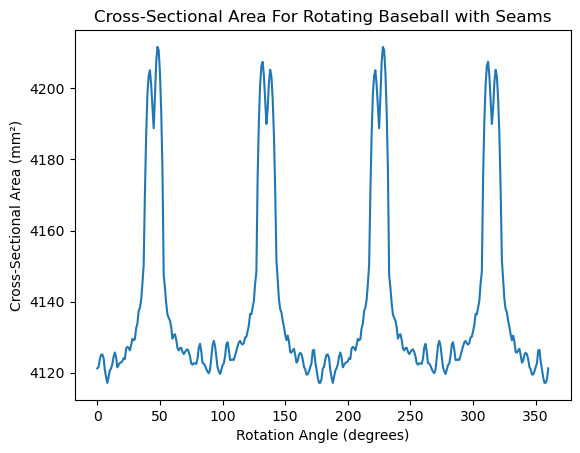

Maximum cross sectional area = 0.00421 m²
Minimum cross sectional area = 0.00412 m²


In [1]:
#--------- Computing the cross-sectional area -----------

import sys
import importlib, subprocess, sys

for package in ['trimesh', 'shapely', 'numpy', 'pandas', 'matplotlib']:
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

import shapely
import trimesh
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the STL file
mesh = trimesh.load_mesh('/Users/maxmoss/Desktop/baseball.STL')


center = mesh.centroid

# Define rotation angles and array for areas
angles = np.linspace(0, 360, 361)

areas = []

# Loop over rotation angles and compute cross-sectional area
for angle in angles:
    rotation = trimesh.transformations.rotation_matrix(
        np.radians(angle), [0, 0, 1], center
    )
    rotated = mesh.copy()
    rotated.apply_transform(rotation)
    
    section = rotated.section(plane_origin=center, plane_normal=[0, 1, 0])
    if section is not None:
        slice_2D, _ = section.to_2D()
        areas.append(slice_2D.area)
    else:
        areas.append(np.nan)

# Plot cross-sectional area vs rotation angle
plt.plot(angles, areas)
plt.title('Cross-Sectional Area For Rotating Baseball with Seams')
plt.xlabel('Rotation Angle (degrees)')
plt.ylabel('Cross-Sectional Area (mm²)')
plt.show()

#print("number of area values:", len(areas))
print(f'Maximum cross sectional area = {max(areas)/1e6:.5f} m²')
print(f'Minimum cross sectional area = {min(areas)/1e6:.5f} m²')


#------------- Interpolation -------------------

from scipy.interpolate import interp1d

angles_new = np.linspace(0,360,361)

f_cubic = interp1d(angles, areas, kind = 'cubic')

areas_cubic = f_cubic(angles_new)

f_area = interp1d(np.radians(angles), np.array(areas)/1e6, kind='cubic', fill_value='extrapolate')

# -------- Plotting with Degrees --------

#plt.plot(angles, areas, 'o', label = 'Origional Data')
#plt.plot(angles_new, areas_cubic, '-', label = 'Cubic Interpolation')
#plt.legend()
#plt.show()

# ------- Plotting with Radians ---------
#theta_rad = np.linspace(0, 2*np.pi, 361)
#plt.plot(np.degrees(theta_rad), f_area(theta_rad)*1e6, '-', label='f_area (radians-based)')
#plt.xlabel("Rotation angle (degrees)")
#plt.ylabel("Cross-sectional area (mm²)")
#plt.legend()
#plt.show()




In [3]:
##Calculations for baseball with no seams (constant cross sectional area)

import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.integrate import quad
from datetime import timedelta

# Constants
g = 9.81  # m/s^2

A = 0.0042  # Constant Cross-sectional area in m^2

m = 0.145  # Mass of baseball in kg

R = 0.0375  # Radius of baseball in meters

rho = 1.225  # kg/m^3

nu = 1.5e-5  # air kinematic viscosity (m²/s)

D = 2 * R    # baseball diameter


# --------- Variables ---------

pitcher_name = "Max Moss"

velo = 86

spin_rate = 1888

td = timedelta(hours=2, minutes=0)

spin_efficiency = .96

VAA = -3.8 #VAA - vertical approach angle (release angle)

extension = 5.3

release_height = 4.24

HAA = 2.21

Cd_mes = .34

IVB_results = []
HB_results = [] 


# ---------- Velocity ----------


v0 = velo * .44704  # Initial speed in m/s 

# ------------ Spin ------------


  # Initial spin
true_spin = spin_rate * spin_efficiency

# ---------- Tilt Conversion ---------


tot_seconds = td.total_seconds()

# --------- Angles ------------

tilt = - (tot_seconds / 60) * .5  # Spin direction angle [ goes from seconds to minutes, 1 min = .5 deg]
HAA_rad = np.radians(HAA)
VAA_rad = np.radians(VAA)

# -------- Release Point -------

rel_dist_home = 60.5 - extension #distance from release point to home plate ft
home_plate = rel_dist_home/3.281 #18.44 , Distance to home plate in meters
r_h = (release_height*12) * .0254   # release height to meters erlander

# -------- Time step ----------
dt = 0.001  

#-------- Functions ----------

def reynolds_number(v):
    return v * D / nu

def Cd_baseball(Re):
    return  0.32 - 0.1 * np.tanh((Re - 2.05e5)/5e4) #0.5 + 0.25 / (1 + np.exp((Re - 3.5e5) / 5e4))

def Cd_speed(v):
    Re = reynolds_number(v)
    return Cd_baseball(Re)

def spin_decay(t):
    tau = .18 + (.014 * v0)
    return   true_spin * np.exp(-t / tau)


def acceleration(vx, vy, vz, t, tilt, theta, f_area):
    v_vec = np.array([vx, vy, vz])
    v = np.linalg.norm(v_vec) #calculates length of velocity vector
      
    if v==0:
        return np.zeros(3)
       
    spin_rpm =  spin_decay(t)
    
    omega = 2 * np.pi * spin_rpm / 60  # rad/s
    
    S = R * omega / v if v != 0 else 0
    S = min(S, 0.2)
    #print('S=',S)
   
    A_inst = f_area  
    
    
    if v >0:
        Cd = .5 
        Fd = 0.5 * Cd * rho * A_inst * v**2 
        F_drag = Fd * (v_vec/v)

    else:
        F_drag = np.zeros(3)
    

# --- Fixed spin axis from tilt ---
    spin_axis = np.array([0, np.sin(np.radians(tilt)), np.cos(np.radians(tilt))])

# --- Lift coefficient ---

    omega_vec = omega * spin_axis
    
    #Lift Coefficient
    
    Cl = 0.09 + 0.6 *S
    Cl = min(Cl, 0.21)
    #print('Cl=', Cl)
# ------ Magnus force --------
    
    omega_hat = omega_vec/np.linalg.norm(omega_vec) # computes the unit vector pointing in direction of w w/ mag 1
    v_hat = v_vec/v
    
    if v !=0:
        Fm = 0.5 * Cl * rho * A_inst * v**2 * np.cross(omega_hat, v_hat)

    else:
        Fm = np.zeros(3)

# ----- Gravitational Force --------
    
    Fg = np.array([0, -m*g, 0])

    F_total = -F_drag +  Fg
     

    return F_total / m
    

def derivatives(s, t, tilt, f_area):
    x, y, z = s[0], s[1], s[2]
    vx, vy, vz = s[3], s[4], s[5]
    theta = s[6]
    ax, ay, az = acceleration(vx, vy, vz, t, tilt, theta, f_area)
    spin_rpm = spin_decay(t)
    omega = 2 * np.pi * spin_rpm / 60  # rad/s
    dtheta = omega
    return np.array([vx, vy, vz, ax, ay, az, dtheta])

def rk4(state, t, dt, tilt, f_area):
    
    k1 = derivatives(state, t, tilt, f_area)
    k2 = derivatives(state + 0.5 * dt * k1, t + 0.5 * dt, tilt, f_area)
    k3 = derivatives(state + 0.5 * dt * k2, t + 0.5 * dt, tilt, f_area)
    k4 = derivatives(state + dt * k3, t + dt, tilt, f_area)
    

    return state + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6

theta0 = 0
x, y, z = 0, r_h , 0
vx, vy, vz = v0*np.cos(VAA_rad)*np.cos(HAA_rad), v0*np.sin(VAA_rad), v0*np.sin(HAA_rad)
#vx, vy, vz = v0*np.cos(VAA_rad), v0*np.sin(VAA_rad), v0*np.sin(HAA_rad)  
state = np.array([x, y, z, vx, vy, vz, theta0])
t = 0


x_vals1 = [x]
y_vals1 = [y]
z_vals1 = [z]
t_vals1 = [t]
spin_vals1 = [spin_decay(0)]

while state[0] <= home_plate:
    state = rk4(state, t, dt, tilt, A)
    t += dt
    x_vals1.append(state[0])
    y_vals1.append(state[1])
    z_vals1.append(state[2])
    t_vals1.append(t)
    spin_vals1.append(spin_decay(t))
    

Ball_no_spin_y = y_vals1[-1]
#print('Ball no spin final y value = ', Ball_no_spin_y)
Ball_no_spin_z = z_vals1[-1]
#print('Ball no spin final z value = ', Ball_no_spin_z)

#------------ Ball with Spin -----------


def reynolds_number(v):
    return (v*D)/nu

def Cd_baseball(Re):
    return  0.32 - 0.1 * np.tanh((Re - 2.05e5)/5e4) 

def Cd_speed(v):
    Re = reynolds_number(v)
    #print('Re = ', Re)
    return Cd_baseball(Re)

def spin_decay(t):
    tau = .18 + (.014 * v0)
    return   true_spin * np.exp(-t / tau)


def acceleration(vx, vy, vz, t, tilt, theta, f_area):
    v_vec = np.array([vx, vy, vz])
    v = np.linalg.norm(v_vec)
      
    if v==0:
        return np.zeros(3)
       
    spin_rpm =  spin_decay(t)
    
    omega = 2 * np.pi * spin_rpm / 60  # rad/s
    
    S = R * omega / v if v != 0 else 0
    S = min(S, 0.3)
    #print('S=',S)
   
    A_inst = float(f_area(theta % (2 * np.pi) ))  

    
    if v >0:
        Cd = Cd_mes #Cd_speed(v)
        #print(Cd)
        Fd = 0.5 * Cd * rho * A_inst * v**2
        F_drag = Fd * (v_vec/v)
        
    else:
        F_drag = np.zeros(3)
        

   
    spin_axis = np.array([0, 
                          np.sin(np.radians(tilt)), 
                          np.cos(np.radians(tilt))
                         ])
    spin_axis = spin_axis / np.linalg.norm(spin_axis)
    
    #Lift Coefficient
    
    Cl = 0.09 + 0.6 *S
    Cl = min(Cl, 0.21)
    #print('Cl=', Cl)

# ------ Magnus force --------
    
    
    v_hat = v_vec/v
    omega_vec = omega * spin_axis
    omega_hat = omega_vec/np.linalg.norm(omega_vec)
             
    if v !=0:
        Fm = 0.5 * Cl * rho * A_inst * v**2 * np.cross(omega_hat, v_hat)

    else:
        Fm = np.zeros(3)

# ----- Gravitational Force --------
    
    Fg = np.array([0, -m*g, 0])

    F_total = -F_drag + Fm +  Fg
     

    return F_total / m
    

def derivatives(s, t, tilt, f_area):
    x, y, z = s[0], s[1], s[2] ##line not needed as x, y, and z aren't used within the function - AZD
    vx, vy, vz = s[3], s[4], s[5]
    theta = s[6]
    ax, ay, az = acceleration(vx, vy, vz, t, tilt, theta, f_area)
    spin_rpm = spin_decay(t)
    omega = 2 * np.pi * spin_rpm / 60  # rad/s
    dtheta = omega
    return np.array([vx, vy, vz, ax, ay, az, dtheta])

def rk4(state, t, dt, tilt, f_area):
    
     k1 = derivatives(state, t, tilt, f_area)
     k2 = derivatives(state + 0.5 * dt * k1, t + 0.5 * dt, tilt, f_area)
     k3 = derivatives(state + 0.5 * dt * k2, t + 0.5 * dt, tilt, f_area)
     k4 = derivatives(state + dt * k3, t + dt, tilt, f_area)
    

     return state + dt *(k1 + 2 * k2 + 2 * k3 + k4) / 6



theta0 = 0
x, y, z = 0, r_h , 0
vx, vy, vz = v0*np.cos(VAA_rad)*np.cos(HAA_rad), v0*np.sin(VAA_rad), v0*np.sin(HAA_rad)
#vx, vy, vz = v0*np.cos(VAA_rad), v0*np.sin(VAA_rad), v0*np.sin(HAA_rad) 
state = np.array([x, y, z, vx, vy, vz, theta0])
t = 0


x_vals = [x]
y_vals = [y]
z_vals = [z]
A_vals = [f_area(theta0)]
t_vals = [t]
spin_vals = [spin_decay(0)]

while state[0] <= home_plate:
    state = rk4(state, t, dt, tilt, f_area)
    t += dt
    x_vals.append(state[0])
    y_vals.append(state[1])
    z_vals.append(state[2])
    A_vals.append(float(f_area(state[6] % (2 * np.pi))))
    t_vals.append(t)
    spin_vals.append(spin_decay(t))
    

                  
# ------- Final values ---------

print('Pitcher Name:', pitcher_name, 
      'Velo =', velo,'mph' , 
      'Tilt =', tilt,'deg'  ,
      'Spin Rate=', spin_rate, 
      'Spin Efficiency= ', spin_efficiency,  
      'Active Spin=',  true_spin, 
      'Release Height =', r_h,'m',
      'Release Angle = ', VAA,
      'Cd = ', Cd_mes)

# ------ Horizontal Break --------

HB = ((z_vals[-1]- Ball_no_spin_z)*39.37)#* np.sin(gyro_angle)

print('HB:', HB, 'in')

# ------ Induced Vertical Break -------

IVB = (y_vals[-1] - Ball_no_spin_y) * 39.37
print('IVB = ', IVB, 'in')

# ----- Flight Time --------

print(f"Total flight time: {t:.4f} s")

v_final = np.linalg.norm(state[3:6])
Re_final = reynolds_number(v_final)


IVB_results.append(IVB)
HB_results.append(HB)

print(f"Final Velocity: {v_final * 2.23694:.1f} mph")
print(f"Final Reynolds Number: {Re_final:.2e}")

Pitcher Name: Max Moss Velo = 86 mph Tilt = -60.0 deg Spin Rate= 1888 Spin Efficiency=  0.96 Active Spin= 1812.48 Release Height = 1.292352 m Release Angle =  -3.8 Cd =  0.34
HB: 15.597923187208822 in
IVB =  10.443362545061687 in
Total flight time: 0.4620 s
Final Velocity: 78.8 mph
Final Reynolds Number: 1.76e+05


In [5]:
## Calculations with changing cross-sectional area


import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.integrate import quad
from datetime import timedelta





def reynolds_number(v):
    return (v*D)/nu

def Cd_baseball(Re):
    return  0.32 - 0.1 * np.tanh((Re - 2.05e5)/5e4) 

def Cd_speed(v):
    Re = reynolds_number(v)
    #print('Re = ', Re)
    return Cd_baseball(Re)

def spin_decay(t):
    tau = .18 + (.014 * v0)
    return   true_spin * np.exp(-t / tau)


def acceleration(vx, vy, vz, t, tilt, theta, f_area):
    v_vec = np.array([vx, vy, vz])
    v = np.linalg.norm(v_vec)
      
    if v==0:
        return np.zeros(3)
       
    spin_rpm =  spin_decay(t)
    
    omega = 2 * np.pi * spin_rpm / 60  # rad/s
    
    S = R * omega / v if v != 0 else 0
    S = min(S, 0.3)
    #print('S=',S)
   
    A_inst = float(f_area(theta % (2 * np.pi) ))  

    
    if v >0:
        Cd = Cd_mes #Cd_speed(v)
        #print(Cd)
        Fd = 0.5 * Cd * rho * A_inst * v**2
        F_drag = Fd * (v_vec/v)
        
    else:
        F_drag = np.zeros(3)
        
    spin_axis = np.array([0, 
                          np.sin(np.radians(tilt)), 
                          np.cos(np.radians(tilt))
                         ])
    spin_axis = spin_axis / np.linalg.norm(spin_axis)
    
    #Lift Coefficient
    
    Cl = 0.09 + 0.6 *S
    Cl = min(Cl, 0.21)
    #print('Cl=', Cl)

# ------ Magnus force --------
    
    
    v_hat = v_vec/v
    omega_vec = omega * spin_axis
    omega_hat = omega_vec/np.linalg.norm(omega_vec)
             
    if v !=0:
        Fm = 0.5 * Cl * rho * A_inst * v**2 * np.cross(omega_hat, v_hat)

    else:
        Fm = np.zeros(3)

# ----- Gravitational Force --------
    
    Fg = np.array([0, -m*g, 0])

    F_total = -F_drag + Fm +  Fg
     

    return F_total / m
    

def derivatives(s, t, tilt, f_area):
    x, y, z = s[0], s[1], s[2] 
    vx, vy, vz = s[3], s[4], s[5]
    theta = s[6]
    ax, ay, az = acceleration(vx, vy, vz, t, tilt, theta, f_area)
    spin_rpm = spin_decay(t)
    omega = 2 * np.pi * spin_rpm / 60  # rad/s
    dtheta = omega
    return np.array([vx, vy, vz, ax, ay, az, dtheta])

def rk4(state, t, dt, tilt, f_area):
    
     k1 = derivatives(state, t, tilt, f_area)
     k2 = derivatives(state + 0.5 * dt * k1, t + 0.5 * dt, tilt, f_area)
     k3 = derivatives(state + 0.5 * dt * k2, t + 0.5 * dt, tilt, f_area)
     k4 = derivatives(state + dt * k3, t + dt, tilt, f_area)
    

     return state + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6


theta0 = 0
x, y, z = 0, r_h , 0
vx, vy, vz = v0*np.cos(VAA_rad)*np.cos(HAA_rad), v0*np.sin(VAA_rad), v0*np.sin(HAA_rad)

state = np.array([x, y, z, vx, vy, vz, theta0])
t = 0


x_vals = [x]
y_vals = [y]
z_vals = [z]
A_vals = [f_area(theta0)]
t_vals = [t]
spin_vals = [spin_decay(0)]

while state[0] <= home_plate:
    state = rk4(state, t, dt, tilt, f_area)
    t += dt
    x_vals.append(state[0])
    y_vals.append(state[1])
    z_vals.append(state[2])
    A_vals.append(float(f_area(state[6] % (2 * np.pi))))
    t_vals.append(t)
    spin_vals.append(spin_decay(t))
    
                  
# ------- Final values ---------

print('Pitcher Name:', pitcher_name, 
      'Velo =', velo,'mph' , 
      'Tilt =', tilt,'deg'  ,
      'Spin Rate=', spin_rate, 
      'Spin Efficiency= ', spin_efficiency,  
      'Active Spin=',  true_spin, 
      'Release Height =', r_h,'m',
      'Release Angle = ', VAA)

# ------ Horizontal Break --------

HB = ((z_vals[-1]- Ball_no_spin_z)*39.37)

print('HB:', HB, 'in')

# ------ Induced Vertical Break -------

IVB = (y_vals[-1] - Ball_no_spin_y) * 39.37
print('IVB = ', IVB, 'in')

# ----- Flight Time --------

print(f"Total flight time: {t:.4f} s")

v_final = np.linalg.norm(state[3:6])
Re_final = reynolds_number(v_final)

IVB_results.append(IVB)
HB_results.append(HB)

print(f"Final Velocity: {v_final * 2.23694:.1f} mph")

print(f"Final Reynolds Number: {Re_final:.2e}")

Pitcher Name: Max Moss Velo = 86 mph Tilt = -60.0 deg Spin Rate= 1888 Spin Efficiency=  0.96 Active Spin= 1812.48 Release Height = 1.292352 m Release Angle =  -3.8
HB: 15.597923187208822 in
IVB =  10.443362545061687 in
Total flight time: 0.4620 s
Final Velocity: 78.8 mph
Final Reynolds Number: 1.76e+05


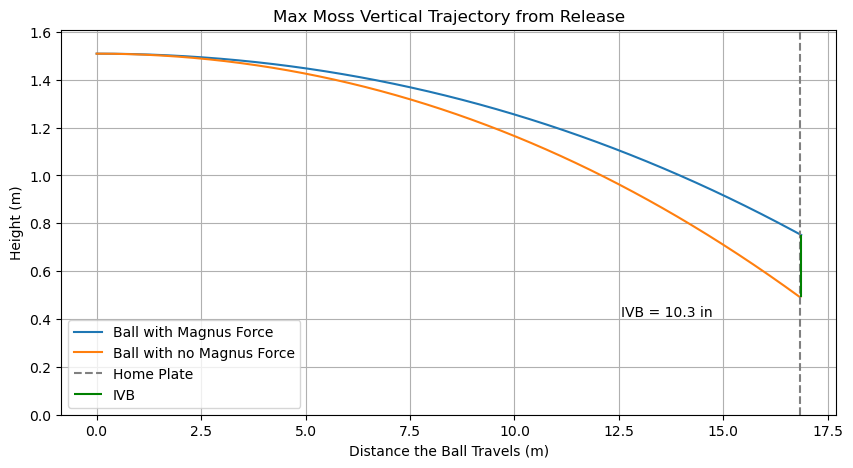

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label='Ball with Magnus Force')
plt.plot(x_vals1, y_vals1, label='Ball with no Magnus Force')
plt.text(12.55, 0.41, 'IVB = 10.3 in')  #f'IVB = {IVB:.2f}'
plt.title("Max Moss Vertical Trajectory from Release")
plt.xlabel("Distance the Ball Travels (m)")
plt.ylabel("Height (m)")
plt.grid(True)
plt.axvline(home_plate, color='grey', linestyle='--', label='Home Plate')
plt.vlines(x = x_vals[-1], ymin = y_vals1[-1], ymax = y_vals[-1], color='green', label = 'IVB')
plt.ylim(0, y_vals[0]+.1)
plt.legend()
plt.savefig('IVB(moss3).jpg')
plt.show()

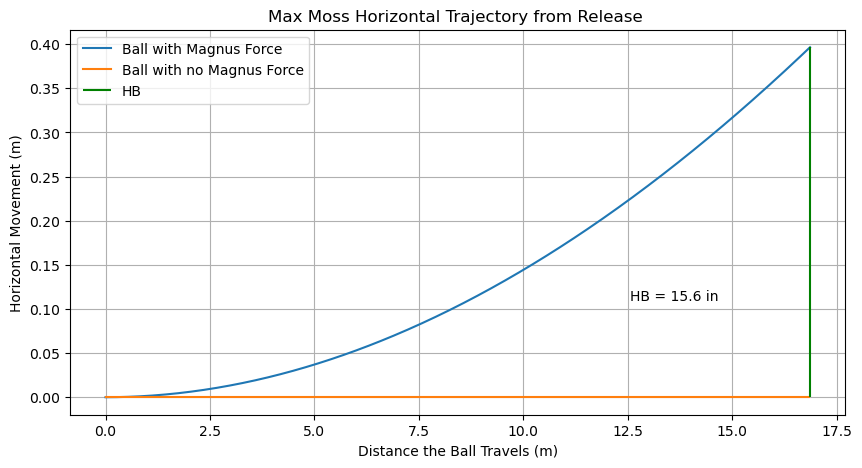

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(x_vals, z_vals, label='Ball with Magnus Force')
plt.plot(x_vals1, z_vals1, label = 'Ball with no Magnus Force')
plt.text(12.55, 0.11, 'HB = 15.6 in')
plt.title("Max Moss Horizontal Trajectory from Release ")
plt.xlabel("Distance the Ball Travels (m)")
plt.ylabel("Horizontal Movement (m)")
plt.grid(True)
#plt.axvline(home_plate, color='red', linestyle='--', label='Home Plate')
plt.vlines(x = x_vals[-1], ymin = z_vals1[-1], ymax = z_vals[-1], color='green', label = 'HB')
plt.legend()
plt.savefig('HB_(moss3).jpg')
plt.show()



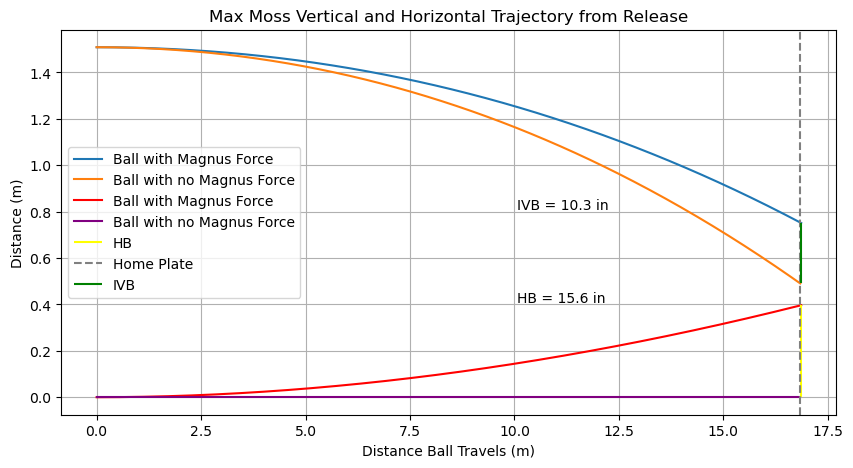

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label='Ball with Magnus Force')
plt.plot(x_vals1, y_vals1, label='Ball with no Magnus Force')

plt.plot(x_vals, z_vals, color = 'red', label='Ball with Magnus Force')
plt.plot(x_vals1, z_vals1, color = 'purple', label = 'Ball with no Magnus Force')
plt.vlines(x = x_vals[-1], ymin = z_vals1[-1], ymax = z_vals[-1], color='yellow', label = 'HB')
plt.title("Max Moss Vertical and Horizontal Trajectory from Release")
plt.xlabel("Distance Ball Travels (m)")
plt.ylabel("Distance (m)")
plt.grid(True)
plt.axvline(home_plate, color='grey', linestyle='--', label='Home Plate')
plt.vlines(x = x_vals[-1], ymin = y_vals1[-1], ymax = y_vals[-1], color='green', label = 'IVB')
plt.text(10.05, .81, 'IVB = 10.3 in')
plt.text(10.05, 0.41, 'HB = 15.6 in')
plt.legend()
plt.savefig('Both(moss3).jpg')
plt.show()

In [31]:
# ------ Percent Diff Calculation ---------

model_ivb = 10.3
game_ivb = 10.7

model_hb = 15.6
game_hb = 15.4

IVB_percent_diff = np.abs((game_ivb - model_ivb)/game_ivb)*100

HB_percent_diff = np.abs((game_hb - model_hb)/game_hb)*100

print('IVB Percent Diff:', IVB_percent_diff)
print('HB Percent Diff:', HB_percent_diff)



IVB Percent Diff: 3.738317757009333
HB Percent Diff: 1.298701298701294


In [9]:
# ------- Absolute Error --------

mivb = float(input("Model IVB:"))
givb = float(input("Game IVB:"))

mhb = float(input("Model HB:"))
ghb = float(input("Game HB:"))

IVB_error = np.abs(mivb - givb)

HB_error = np.abs(mhb - ghb)
print('IVB:', IVB_error)
print('HB:', HB_error)

Model IVB: 17.5
Game IVB: 16.4
Model HB: 2.1
Game HB: 1.1


IVB: 1.1000000000000014
HB: 1.0


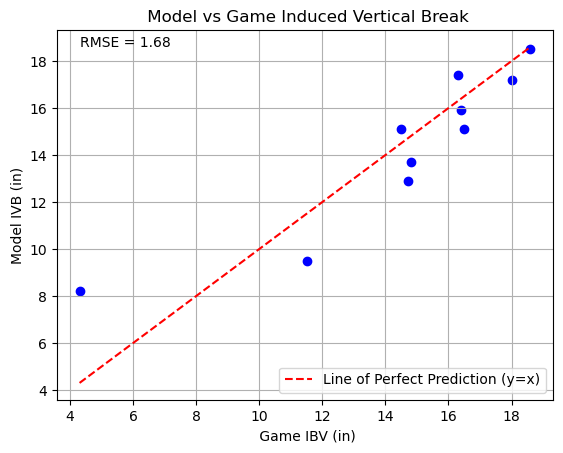

In [61]:
# ------- RSME IVB ---------

game_ivb_arr = np.array([14.5, 16.4, 16.3, 14.8, 14.7, 16.5, 18, 4.3, 18.6, 11.5])
model_ivb_arr = np.array([15.1, 15.9, 17.4, 13.7, 12.9, 15.5, 17.2, 8.2, 18.5, 9.5])


min_val = min(game_ivb_arr.min(), model_ivb_arr.min())
max_val = max(game_ivb_arr.max(), model_ivb_arr.max())

x_line = np.linspace(min_val, max_val, 100)

plt.plot(x_line, x_line, color = 'red', linestyle='--', label = 'Line of Perfect Prediction (y=x)')

rmse_ivb = np.sqrt(np.mean((game_ivb_arr - model_ivb_arr)**2))

plt.text(min_val, max_val, f'RMSE = {rmse_ivb:.2f}')
plt.scatter(game_ivb_arr, model_ivb_arr, color = 'blue')
plt.xlabel(' Game IBV (in)')
plt.ylabel('Model IVB (in)')
plt.title(' Model vs Game Induced Vertical Break')
plt.legend(loc = 'lower right')
plt.grid(True)
plt.savefig('RMSE_IVB.jpg')
plt.show()

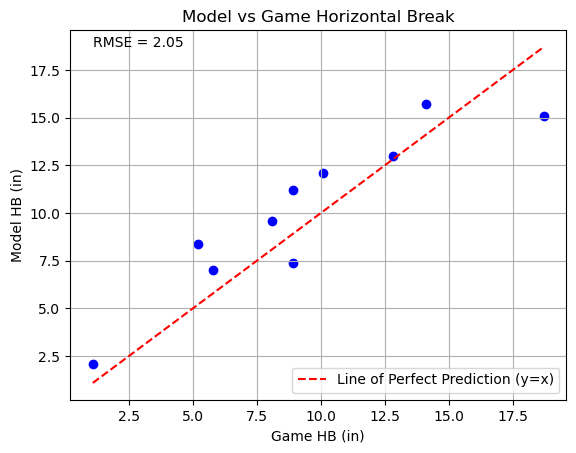

In [59]:
# ------- RMSE HB --------

game_hb_arr = np.array([ 5.2, 14.1, 5.8, 12.8, 10.1, 8.9, 8.1, 18.7, 8.9, 1.1])
model_hb_arr = np.array([8.4, 15.7, 7, 13, 12.1, 11.2, 9.6, 15.1, 7.4, 2.1])

min_val = min(game_hb_arr.min(), model_hb_arr.min())
max_val = max(game_hb_arr.max(), model_hb_arr.max())

x_line = np.linspace(1.1, 18.7, 100)

rmse_hb = np.sqrt(np.mean((game_hb_arr - model_hb_arr)**2))
plt.text(min_val, max_val, f'RMSE = {rmse_hb:.2f}')
plt.plot(x_line, x_line, color = 'red', linestyle = '--', label = 'Line of Perfect Prediction (y=x)')
plt.scatter(game_hb_arr, model_hb_arr, color = 'blue')
plt.grid(True)
plt.title('Model vs Game Horizontal Break')
plt.xlabel('Game HB (in)')
plt.ylabel('Model HB (in)')
plt.legend(loc = 'lower right')
plt.savefig('RMSE_HB.jpg')
plt.show()

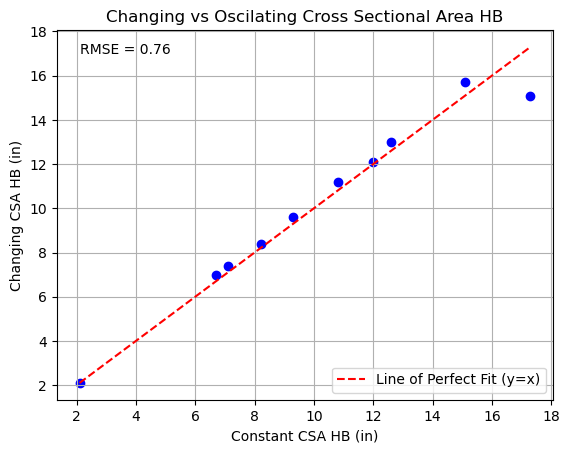

In [69]:
# ------ RMSE for changing vs oscillating CSA -------

const_hb_arr = np.array([ 8.2, 2.1, 6.7, 12.6, 12.0, 10.8, 9.3, 17.3, 7.1, 15.1])

changing_hb_arr = np.array([ 8.4, 2.1, 7, 13, 12.1, 11.2, 9.6, 15.1, 7.4, 15.7])

x_line = np.linspace(2.1, 17.3 , 100)

rmse_hb3 = np.sqrt(np.mean((changing_hb_arr-const_hb_arr)**2))

plt.text(2.1 , 17 , f'RMSE = {rmse_hb3:.2f}')

plt.plot(x_line, x_line, color = 'red', linestyle = '--', label = 'Line of Perfect Fit (y=x)')
plt.scatter(const_hb_arr, changing_hb_arr, color = 'blue')
plt.grid(True)
plt.title('Changing vs Oscilating Cross Sectional Area HB')
plt.xlabel('Constant CSA HB (in)')
plt.ylabel('Changing CSA HB (in)')
plt.legend(loc = 'lower right')
plt.savefig('Const vs Changing HB RMSE.jpg')
plt.show()

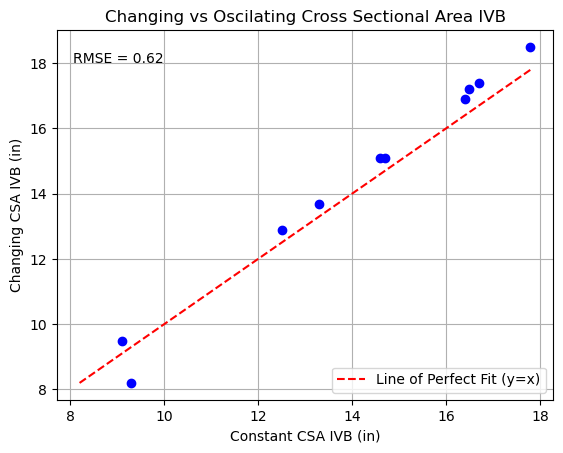

In [67]:
# ------ RMSE for changing vs oscillating CSA -------

const_ivb_arr = np.array([ 14.7,  16.4, 16.7, 13.3, 12.5, 14.6, 16.5, 9.3, 17.8, 9.1])

changing_ivb_arr = np.array([15.1, 16.9, 17.4, 13.7, 12.9, 15.1, 17.2, 8.2, 18.5, 9.5])

x_line = np.linspace(8.2, 17.8, 100)

rmse_ivb3 = np.sqrt(np.mean((const_ivb_arr - changing_ivb_arr)**2))

plt.text( 8.05, 18, f'RMSE = {rmse_ivb3:.2f}')

plt.plot(x_line, x_line, color = 'red', linestyle = '--', label = 'Line of Perfect Fit (y=x)')
plt.scatter(const_ivb_arr, changing_ivb_arr, color = 'blue')
plt.grid(True)
plt.title('Changing vs Oscilating Cross Sectional Area IVB')
plt.xlabel('Constant CSA IVB (in)')
plt.ylabel('Changing CSA IVB (in)')
plt.legend(loc = 'lower right')
plt.savefig('Const vs Changing IVB RMSE.jpg')
plt.show()